In [1]:
import matplotlib.pyplot as plt
import numpy as np
from mytools.construct import all_armchair as struct
import sisl
from scipy.spatial import cKDTree

In [2]:
def plot_atoms(xyz, ax=None):
    if ax is None:
        fig, ax = plt.subplots()
    else:
        pass
    
    ax.scatter(xyz[:, 0], xyz[:, 1], s=120)
    coords = xyz[:, :2]
    for i, (x, y) in enumerate(coords):
        ax.text(x, y, str(i), fontsize=8, verticalalignment='center', horizontalalignment='center',
                bbox=dict(facecolor='white',alpha=0.7,edgecolor='none', pad=0.1)
                )
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.set_title('Atom positions with indices')
    

In [24]:
BOND = 1.42
R = (0.1, BOND+1e-2)
T = (0.0, -2.7)

N1 = 6
N2 = 15

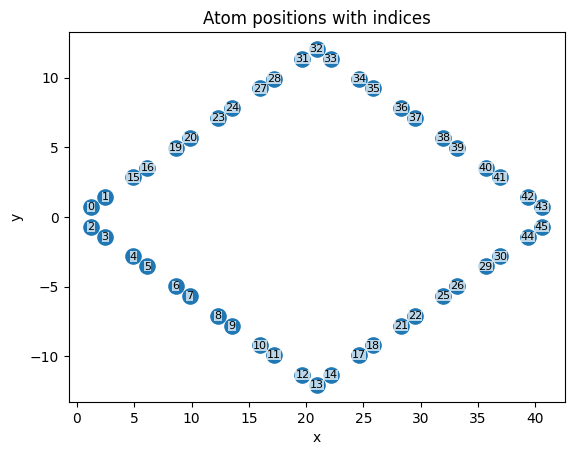

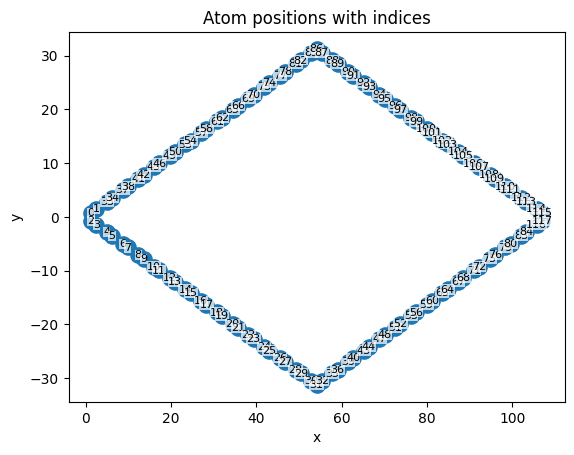

In [25]:
graphene6 = struct(BOND)
Ham0 = sisl.Hamiltonian(graphene6)
Ham0.construct([R, T])

RSE1 = sisl.RealSpaceSE(Ham0, 0, 1, (N1, N1, 1))
RSE2 = sisl.RealSpaceSE(Ham0, 0, 1, (N2, N2, 1))

Ham1 = RSE1.real_space_parent()
Ham2 = RSE2.real_space_parent()

HamElec1, Elec1 = RSE1.real_space_coupling(ret_indices=True)
HamElec2, Elec2 = RSE2.real_space_coupling(ret_indices=True)
plot_atoms(HamElec1.xyz)
plot_atoms(HamElec2.xyz)

In [26]:
xyz1 = HamElec1.xyz
xyz2 = HamElec2.xyz

test = HamElec2
np.isclose(test.geometry.icell.T, np.linalg.inv(test.cell), atol=1e-8)

array([[ True,  True,  True],
       [ True,  True,  True],
       [ True,  True,  True]])

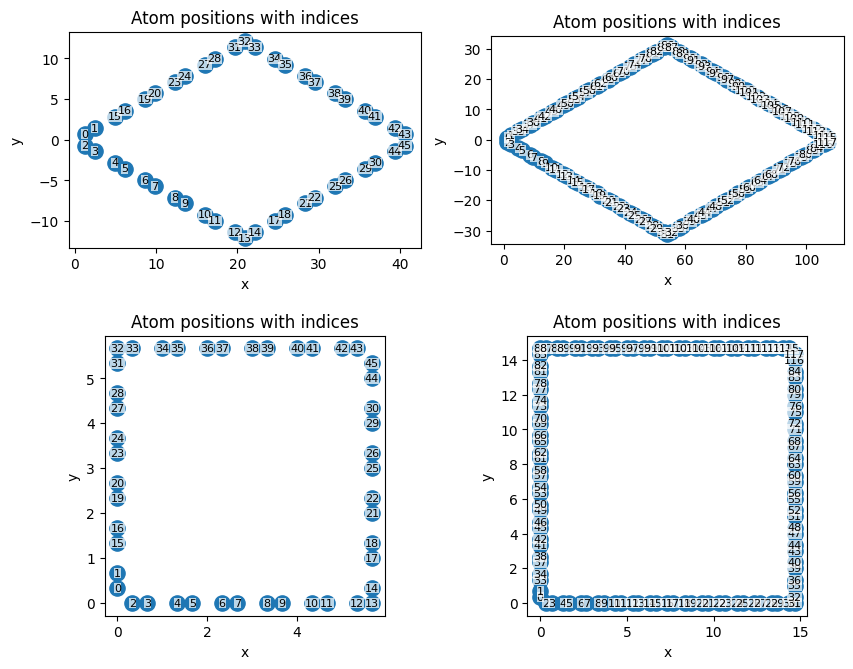

In [27]:
use_custom = False


if use_custom:
    Inv = lambda H: np.linalg.inv(H.cell)
else:
    Inv = lambda H: H.icell.T


frac1 = xyz1 @ Inv(Ham0)
frac2 = xyz2 @ Inv(Ham0)

fig, axes = plt.subplots(2, 2, figsize=(10, 8))
plot_atoms(xyz1, ax=axes[0, 0])
# plot_atoms(Ham1.remove(Elec1).xyz, ax=axes[0, 0])

plot_atoms(xyz1 @ Inv(Ham0), ax=axes[1,0])
# plot_atoms(Ham1.remove(Elec1).xyz @ Inv(Ham0), ax=axes[1,0])

plot_atoms(xyz2, ax=axes[0,1])
# plot_atoms(Ham2.remove(Elec2).xyz, ax=axes[0,1])

plot_atoms(xyz2 @ Inv(Ham0), ax=axes[1, 1])
# plot_atoms(Ham2.remove(Elec2).xyz @ Inv(Ham0), ax=axes[1, 1])


for ax in axes.flatten():
    ax.set_aspect('equal')

if use_custom:
    for ax, m in zip(axes[1, :], [np.max(frac1), np.max(frac2)]):
        ax.set_xlabel('x (fractional)')
        ax.set_xticks(np.arange(0, np.ceil(m)+1, 1))
        ax.set_yticks(np.arange(0, np.ceil(m)+1, 1))
# fig.set_constrained_layout(True)

/tmp/ipykernel_159249/903740816.py:3: RuntimeWarning: invalid value encountered in divide
  plot_atoms(frac1 / np.max(frac1, axis=0, keepdims=True), ax=axes[0])
/tmp/ipykernel_159249/903740816.py:4: RuntimeWarning: invalid value encountered in divide
  plot_atoms(frac2 / np.max(frac2, axis=0, keepdims=True), ax=axes[1])


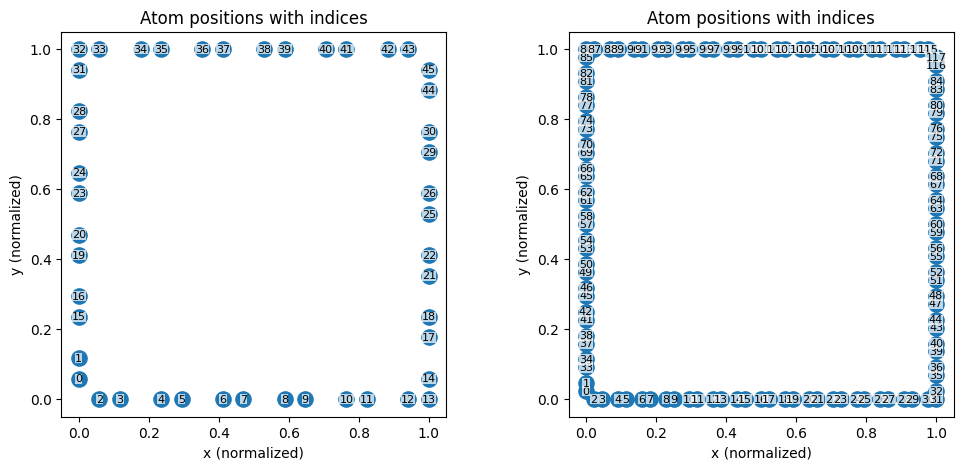

In [28]:


fig, axes = plt.subplots(1, 2, figsize=(12, 5))

plot_atoms(frac1 / np.max(frac1, axis=0, keepdims=True), ax=axes[0])
plot_atoms(frac2 / np.max(frac2, axis=0, keepdims=True), ax=axes[1])

for ax in axes:
    ax.set_aspect(1.)
    ax.set_xlabel('x (normalized)')
    ax.set_ylabel('y (normalized)')

In [29]:
testcoords = HamElec1.xyz
testcell = HamElec1.cell
# testcell = Ham0.cell
testfrac = testcoords @ np.linalg.inv(testcell)
testfrac.min(), testfrac.max()

(np.float64(-1.1082249706684756e-16), np.float64(0.9444444444444446))

In [30]:
def get_fractional(geom, coords=None):
    """Map Cartesion coordinates to fractional coordinates, 
    between 0 and 1 representing position relative to unitcell vertices."""
    Inv = geom.icell.T[:2, :2]
    if coords is not None:
        coords = coords[:, :2]
    else:
        coords = geom.xyz[:, :2]
    # elif (coords is not None) and (coords.shape[1] == 3):
    #     coords = geom.xyz[:, :2]
    frac = coords @ Inv
    return frac / np.max(frac, axis=0, keepdims=True)

def get_corner_atoms(coords, corner, k=1):
    
    tree = cKDTree(coords)
    dists, idxs = tree.query(corner, k=k)
    return np.sort(idxs)


# def find_corners(fcoords):
#     """Find the corners of the fractional coordinate space."""
#     corners = np.array([[0, 0], [1, 0], [0, 1], [1, 1]])
#     tree = cKDTree(corners)
#     _, indices = tree.query(fcoords)
#     indices = np.sort(indices)
#     print(indices)
#     return indices

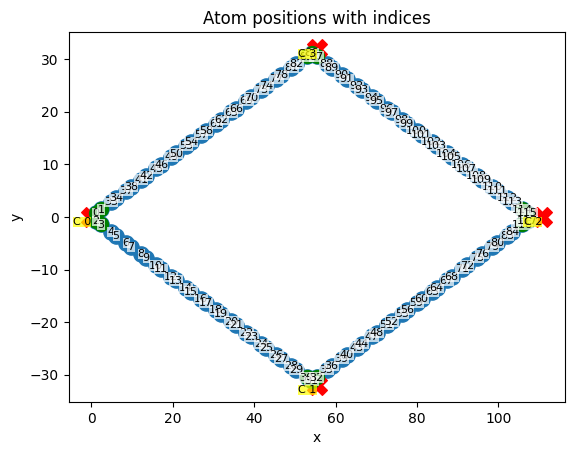

In [31]:
H = HamElec2
coords = H.xyz
frac1 = get_fractional(H)
fig, ax = plt.subplots()
plot_atoms(coords, ax=ax)
A, B, C = H.cell
corners = np.array([A-A, A, A+B, B])

ax.scatter(corners[:, 0], corners[:, 1], color='red', s=200, marker='X')
for ic, (c, k) in enumerate(zip(corners, [4,3,4,3])):
    ax.text(c[0], c[1], f'C {ic}', fontsize=8, verticalalignment='top', horizontalalignment='right',
            bbox=dict(facecolor='yellow',alpha=0.7, edgecolor='none', pad=0.1)
            )
    idxs = get_corner_atoms(coords, c, k=k)
    ax.scatter(coords[idxs, 0], coords[idxs, 1], color='green', s=100, marker='o')
        

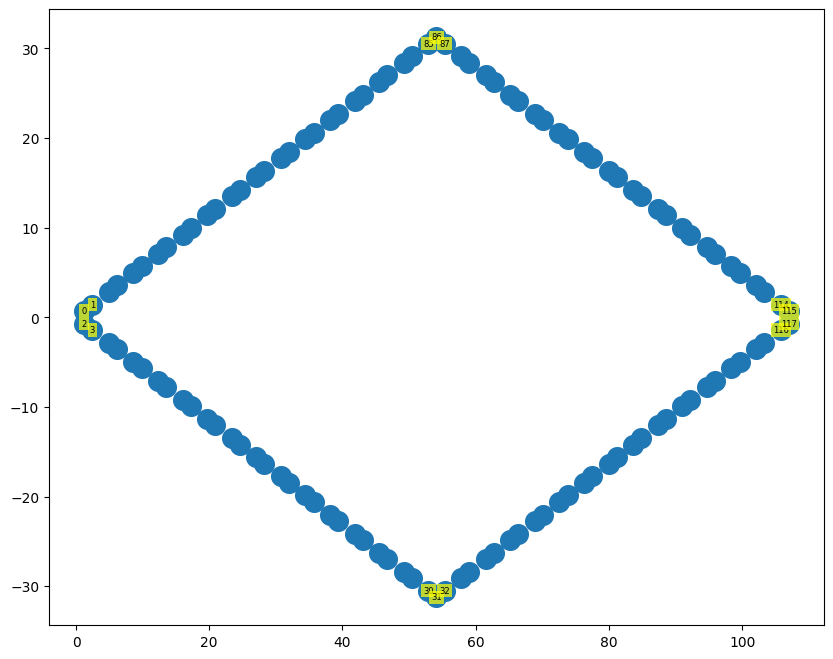

In [32]:
def find_corners(geom):
    A, B, _ = geom.cell
    corners = np.array([A-A, A, A+B, B])
    ks = np.array([4, 3, 4, 3])
    idxs = {}
    labels = ['0', 'A', 'A+B', 'B']
    for c, k, lab in zip(corners, ks, labels):
        idx = get_corner_atoms(geom.xyz, c, k)
        idxs[lab] = idx
    return idxs

H = HamElec2
idxs = find_corners(H)

fig, ax = plt.subplots(figsize=(10, 8))
ax.scatter(H.xyz[:, 0], H.xyz[:, 1], s=200)
for lab, idx in idxs.items():
    # ax.scatter(H.xyz[idx, 0], H.xyz[idx, 1], color='red', s=50, marker='X')
    for i in idx:
        ax.text(H.xyz[i, 0], H.xyz[i, 1], i, fontsize=6, verticalalignment='center', horizontalalignment='center',
                bbox=dict(facecolor='yellow',alpha=0.7, edgecolor='none', pad=1.5)
                )


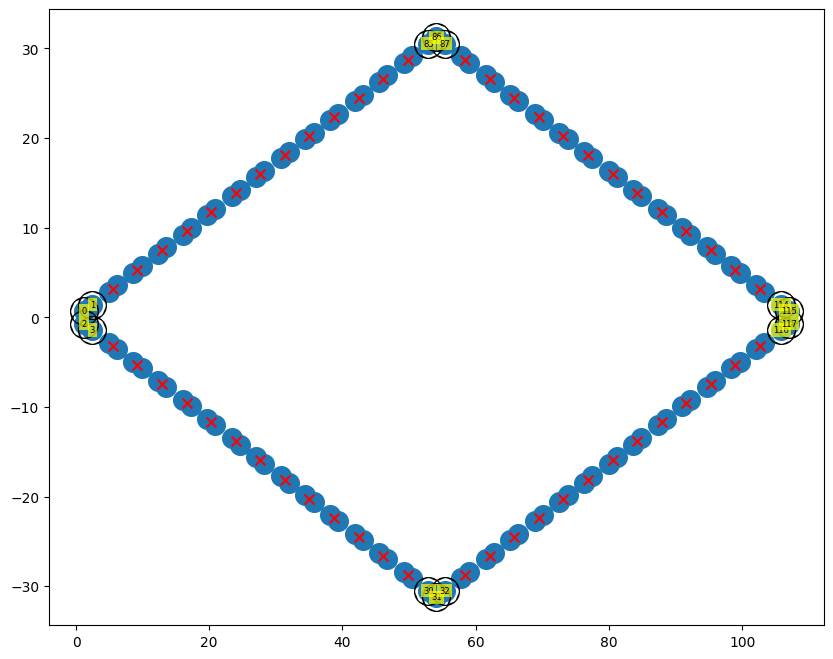

In [33]:
H = HamElec2
idxs = find_corners(H)

edge_atoms = np.delete(np.arange(H.na), np.concatenate(list(idxs.values())))
tree = cKDTree(H.xyz)
dist, ii = tree.query(H.xyz[edge_atoms], k=2)
pair_center = H.xyz[ii[::2]].mean(axis=1, keepdims=True).squeeze()

fig, ax = plt.subplots(figsize=(10, 8))
ax.scatter(H.xyz[:, 0], H.xyz[:, 1], s=200)
for lab, idx in idxs.items():
    ax.scatter(H.xyz[idx, 0], H.xyz[idx, 1], color='red', s=1, marker='o', edgecolors='k', lw=20)
    for i in idx:
        ax.text(H.xyz[i, 0], H.xyz[i, 1], i, fontsize=6, verticalalignment='center', horizontalalignment='center',
                bbox=dict(facecolor='yellow',alpha=0.7, edgecolor='none', pad=1.5)
                )
ax.scatter(pair_center[:, 0], pair_center[:, 1], color='red', s=50, marker='x')

{'0': array([0, 1, 2, 3]), 'A': array([30, 31, 32]), 'A+B': array([114, 115, 116, 117]), 'B': array([85, 86, 87])}


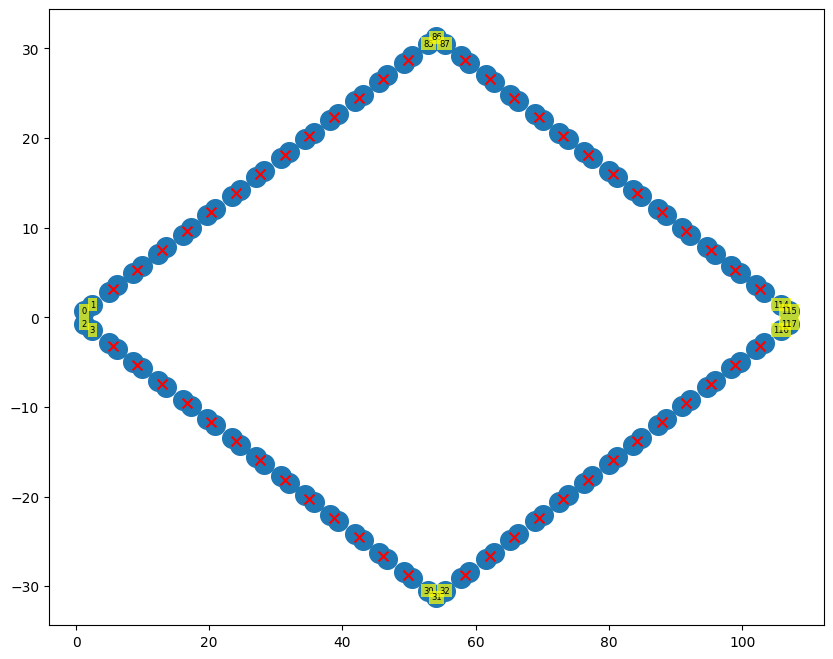

In [34]:
def find_pair_edges(geom, corners):
    edge_atoms = np.delete(np.arange(geom.na), np.concatenate(list(corners.values())))
    tree = cKDTree(geom.xyz)
    dist, ii = tree.query(geom.xyz[edge_atoms], k=2)
    ii = ii[0::2]
    pair_center = geom.xyz[ii].mean(axis=1, keepdims=True).squeeze()
    return pair_center, ii


H = HamElec2
coords = H.xyz
corners = find_corners(H)
print(corners)
pair_center, pair_indices = find_pair_edges(H, corners)
fig, ax = plt.subplots(figsize=(10, 8))
ax.scatter(coords[:, 0], coords[:, 1], s=200)
for cidx in np.concatenate(list(corners.values())):
    ax.text(coords[cidx, 0], coords[cidx, 1], cidx, fontsize=6, verticalalignment='center', horizontalalignment='center',
            bbox=dict(facecolor='yellow',alpha=0.7, edgecolor='none', pad=1.5)
            )
ax.scatter(pair_center[:, 0], pair_center[:, 1], color='red', s=50, marker='x')

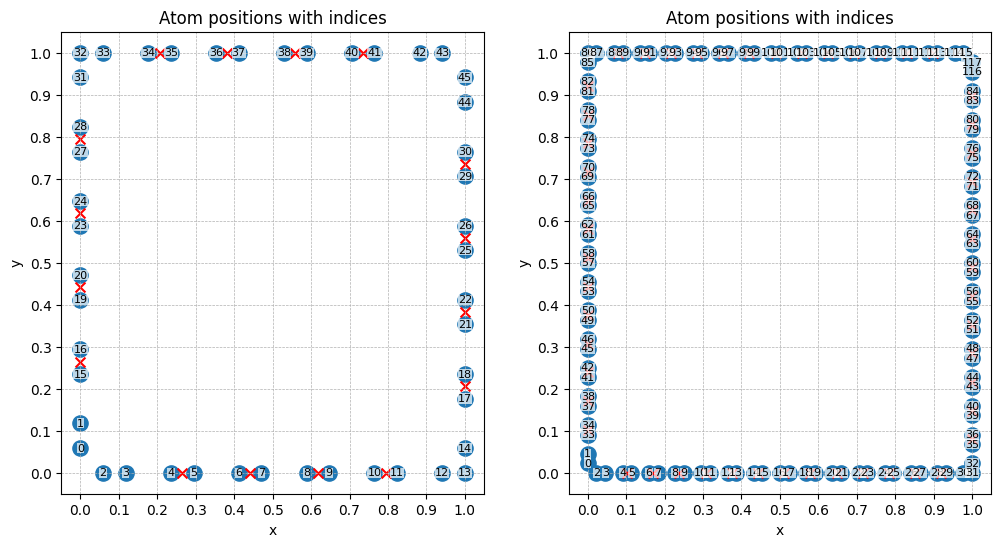

In [35]:
fig, axes = plt.subplots(1, 2, figsize=(12, 6))
for i, H in enumerate([HamElec1, HamElec2]):
    corners = find_corners(H)
    pair_center, pair_indices = find_pair_edges(H, corners)
    frac = get_fractional(H)
    # print(f'Pair center indices: {pair_indices}')
    frac_pair_center = get_fractional(H, coords=pair_center)
    plot_atoms(frac, ax=axes[i])
    axes[i].scatter(frac_pair_center[:, 0], frac_pair_center[:, 1], color='red', s=50, marker='x')
    # axes[i].set_aspect(1.)
    axes[i].grid(which='both', linestyle='--', linewidth=0.5)
    axes[i].set_xticks(np.arange(0, 1.1, 0.1))
    axes[i].set_yticks(np.arange(0, 1.1, 0.1))

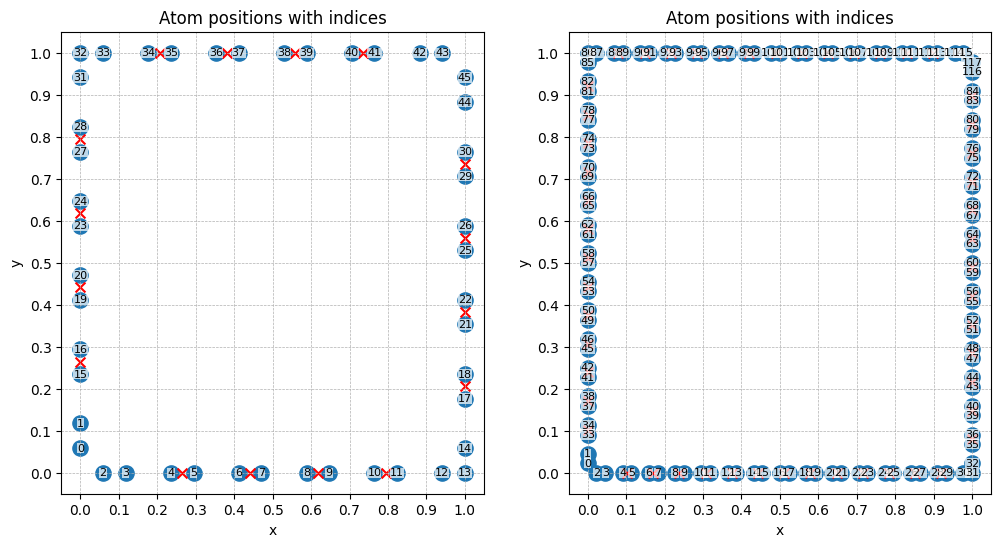

In [36]:
fig, axes = plt.subplots(1, 2, figsize=(12, 6))
for i, H in enumerate([HamElec1, HamElec2]):
    corners = find_corners(H)
    pair_center, pair_indices = find_pair_edges(H, corners)
    frac = get_fractional(H)
    # print(f'Pair center indices: {pair_indices}')
    frac_pair_center = get_fractional(H, coords=pair_center)
    plot_atoms(frac, ax=axes[i])
    axes[i].scatter(frac_pair_center[:, 0], frac_pair_center[:, 1], color='red', s=50, marker='x')
    # axes[i].set_aspect(1.)
    axes[i].grid(which='both', linestyle='--', linewidth=0.5)
    axes[i].set_xticks(np.arange(0, 1.1, 0.1))
    axes[i].set_yticks(np.arange(0, 1.1, 0.1))

## Nearest neigbour strategy
(seems to have too much edge cases)

for N=6 -> 15:
Finding 1 closest points in HamElec2 for each pair center in HamElec1...
[ 0  0  0  0  1  1  1  2  2  3  3  3  3  4  5  4  5  4  5  4  5  6  7  6
  7  6  9  8  9  8  9 10 11 10 11 10 11 10 11 12 12 12 12 13 13 14 14 14
 15 15 15 15]


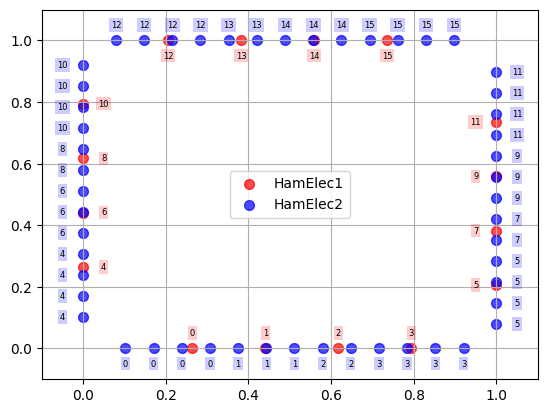

In [44]:
use_cartesian = False
xyz1 = HamElec1.xyz
xyz2 = HamElec2.xyz
frac1 = get_fractional(HamElec1)
frac2 = get_fractional(HamElec2)
c1 = find_corners(HamElec1)
c2 = find_corners(HamElec2)
pc1, eidx1 = find_pair_edges(HamElec1, c1)
pc2, eidx2 = find_pair_edges(HamElec2, c2)

if use_cartesian:
    coords1 = HamElec1.xyz
    coords2 = HamElec2.xyz
    pc1 = pc1[:, :2]
    pc2 = pc2[:, :2]
else:
    coords1 = frac1
    coords2 = frac2
    pc1 = get_fractional(HamElec1, coords=pc1)
    pc2 = get_fractional(HamElec2, coords=pc2)

k = 1
print(f'for N={N1} -> {N2}:\nFinding {k} closest points in HamElec2 for each pair center in HamElec1...')
tree = cKDTree(pc1)
dd, ii = tree.query(pc2, k=k)
print(ii)

tol = 0.05
# print(f'Pair center fractional coordinates in HamElec1: \n{fpc1.round(5)}')
# print(f'Closest points in HamElec2: \n{fpc2[idx].round(3)}')
fig, ax = plt.subplots()
ax.scatter(pc1[:, 0], pc1[:, 1], color='r', s=50, label='HamElec1', alpha=0.7)
ax.scatter(pc2[:, 0], pc2[:, 1], color='blue', s=50, label='HamElec2', alpha=0.7)
for i, idx in enumerate(ii):
    x,y = pc2[i]
    if (x < tol): dx = -0.05
    elif (x > 1 - tol): dx = 0.05
    else: dx = 0
    
    if (y < tol): dy = -0.05
    elif (y > 1-tol): dy = 0.05
    else: dy = 0
    ax.text(x+dx, y+dy, str(idx), fontsize=6, verticalalignment='center', horizontalalignment='center', color='k',
            bbox=dict(facecolor='b',alpha=0.2, edgecolor='none', pad=1.5)
            )

for j, (x,y) in enumerate(pc1):
    if x <= 0.05: dx = 0.05
    elif x >= 0.95: dx = -0.05
    else: dx = 0
    
    if y <= 0.05: dy = 0.05
    elif y >= 0.95: dy = -0.05
    else: dy = 0
    ax.text(x+dx, y+dy, str(j), fontsize=6, verticalalignment='center', horizontalalignment='center', color='k',
            bbox=dict(facecolor='r',alpha=0.2, edgecolor='none', pad=1.5)
            )
# ax.axhline(tol)
# ax.axvline(1-tol)
ax.legend()
if not use_cartesian:
        ax.set(xlim=(0. - 0.1, 1. + 0.1), 
                ylim=(0. - 0.1, 1. + 0.1),)
ax.grid()
# ax.scatter(fpc1[ii[0], 0], fpc1[ii[0], 1], color='red', s=50, marker='x')

In [45]:
def find_equiv_pair(geom1, geom2):
    if geom1.na > geom2.na:
        _tmp = geom1.copy()
        geom1 = geom2.copy()
        geom2 = _tmp.copy()
        del _tmp
    
    assert geom1.na < geom2.na, f"The first Geometry has to be smallest ({geom1.na}, {geom2.na})"
        
    xyz1 = geom1.xyz
    xyz2 = geom2.xyz
    corners1 = find_corners(geom1)
    corners2 = find_corners(geom2)
    pairCenter1, edgeID1 = find_pair_edges(geom1, corners1)
    pairCenter2, edgeID2 = find_pair_edges(geom2, corners2)
    
    fracpairCenter1 = get_fractional(geom1, coords=pairCenter1)
    fracpairCenter2 = get_fractional(geom2, coords=pairCenter2)
    tree = cKDTree(fracpairCenter1)
    dists, pairIndice = tree.query(fracpairCenter2, k=1) # find the coords in fracpairCenter2 that is closest to coords in fracpairCenter1
    
    return corners1, corners2, pairCenter2, edgeID1, pairIndice
    

def dict2array(d):
    lst = list(d.values()) # list of list of values
    flat = np.concatenate(lst) # concatenate list of list to a 1D array
    return flat

{'0': array([0, 1, 2, 3]), 'A': array([12, 13, 14]), 'A+B': array([42, 43, 44, 45]), 'B': array([31, 32, 33])}
[ 4  5  4  5  4  5  4  5  6  7  6  7  6  7  8  9  8  9 10 11 10 11 10 11
 10 11 15 16 17 18 15 16 17 18 15 16 17 18 15 16 17 18 19 20 21 22 19 20
 21 22 19 20 25 26 23 24 25 26 23 24 25 26 27 28 29 30 27 28 29 30 27 28
 29 30 27 28 29 30 34 35 34 35 34 35 34 35 36 37 36 37 38 39 38 39 38 39
 40 41 40 41 40 41 40 41] (104,)
[26 52 78]
jump between : [11 15]
Insert : corners1[A] = [12 13 14]
jump between : [20 25]
Insert : corners1[B] = [31 32 33]
jump between : [30 34]
Insert : corners1[A+B] = [42 43 44 45]
[array([ 4,  5,  4,  5,  4,  5,  4,  5,  6,  7,  6,  7,  6,  7,  8,  9,  8,
        9, 10, 11, 10, 11, 10, 11, 10, 11]), array([15, 16, 17, 18, 15, 16, 17, 18, 15, 16, 17, 18, 15, 16, 17, 18, 19,
       20, 21, 22, 19, 20, 21, 22, 19, 20]), array([25, 26, 23, 24, 25, 26, 23, 24, 25, 26, 27, 28, 29, 30, 27, 28, 29,
       30, 27, 28, 29, 30, 27, 28, 29, 30]), array([34, 35, 3

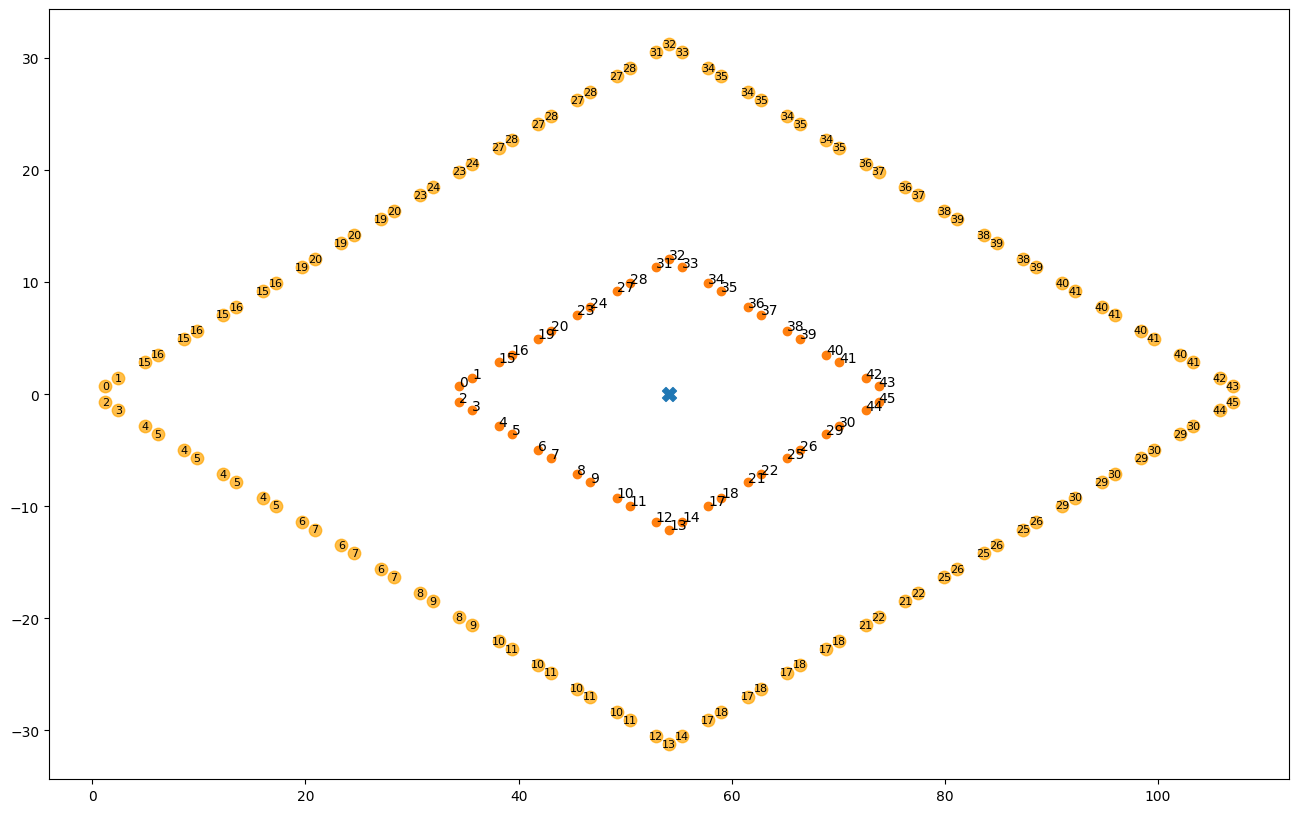

In [76]:
show_centers = False

xy1 = HamElec1.xyz[:, :2]
xy2 = HamElec2.xyz[:, :2]

corners1, corners2, centers, edgeIDs, pairIndice = find_equiv_pair(HamElec1, HamElec2)

g1_to_g2_index = edgeIDs[pairIndice].flatten()

elec_atoms = np.arange(HamElec2.na)
corner_atoms = dict2array(corners2) # convert values of dict to a 1D flat numpy array
edge_atoms = np.delete(elec_atoms, corner_atoms)

fig, ax = plt.subplots(figsize=(16,10))
ax.scatter(*xy2.T, color='orange', s=80, label='HamElec2', alpha=0.7)
if show_centers:
    for i, idx in enumerate(pairIndice):     
        x,y = centers[i, :2]
        ax.text(x, y, edgeIDs[idx], fontsize=8, verticalalignment='center', horizontalalignment='center', color='k',
                bbox=dict(facecolor='orange',alpha=0.1, edgecolor='red', pad=1.5)
                )
else:
    
    for i, (g2idx, g1idx) in enumerate(zip(edge_atoms, g1_to_g2_index)):
        x,y = xy2[g2idx]
        ax.text(x, y, s=g1idx, fontsize=8, verticalalignment='center', horizontalalignment='center', color='k',
                # bbox=dict(facecolor='orange',alpha=0.1, edgecolor='red', pad=1.5)
                )
        
        

for ii, idx in zip(dict2array(corners1), dict2array(corners2)):
    ax.text(*xy2[idx], s=ii, fontsize=8, verticalalignment='center', horizontalalignment='center', color='k',
        # bbox=dict(facecolor='r',alpha=0.1, edgecolor='red', pad=1.5)
        )

# show xy1 shifted to the center of xy2
xy1_shift = xy1 - xy1.mean(axis=0, keepdims=True) + xy2.mean(axis=0, keepdims=True)
ax.scatter(*xy2.mean(axis=0), marker="X", s=100)
ax.scatter(*xy1_shift.T)
for i in range(HamElec1.na):
    ax.text(*xy1_shift[i], i)
    

diffs = np.diff(g1_to_g2_index)
split_indices = np.where(diffs > 3)[0] + 1
parts = np.split(g1_to_g2_index, split_indices)
parts
results = np.concatenate([corners1['0'],
                parts[0],
                corners1['A'],
                parts[1],
                corners1['B'],
                parts[2],
                corners1['A+B']])
print(corners1)
print(g1_to_g2_index, g1_to_g2_index.shape)
print(split_indices)
for key, split in zip(['A', 'B', 'A+B'], split_indices):
    print(f"jump between : {g1_to_g2_index[split-1:split+1]}")
    print(f"Insert : corners1[{key}] = {corners1[key]}")
print(parts)
print(results, results.shape)

(92,)


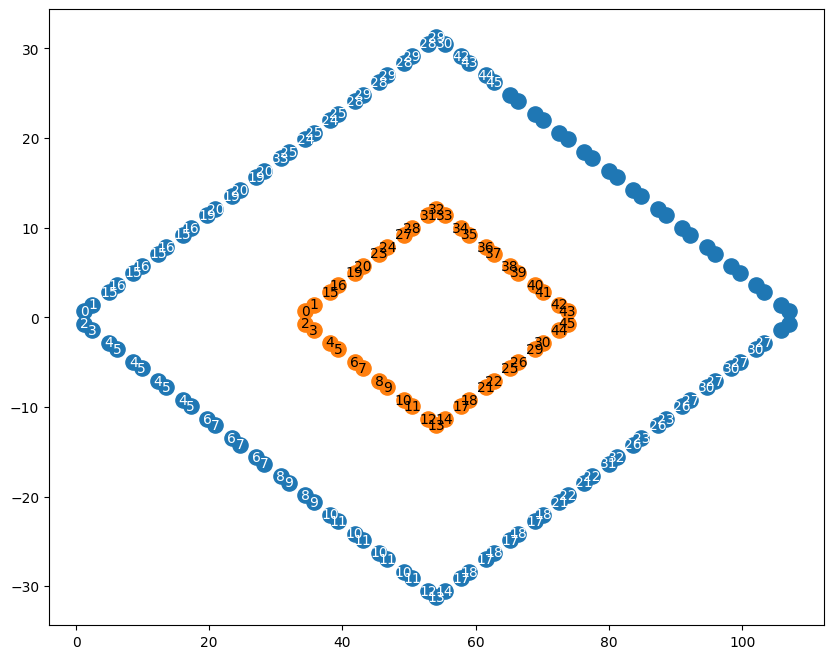

In [ ]:
def map_index(geom1, geom2):
    corners1, corners2, centers, edgeIDs, pairIndices = find_equiv_pair(geom1, geom2)
    g1_to_g2_edgeIdx = edgeIDs[pairIndices].flatten()
    
    # take difference between subsequent indices
    diffs = np.diff(g1_to_g2_edgeIdx)
    # find indices where elements of diff increase more than 3 (going from one edge to another) 
    split_indices = np.where(diffs > 3)[0] + 1
    # split edge indices to list of arrays for each edge
    parts = np.split(g1_to_g2_edgeIdx, split_indices)
    g1_to_g2 = np.concatenate([
        corners1['0'], # first corner
        parts[0], # first edge
        corners1['A'], # corner after first edge
        parts[1], # both transverse edges
        corners1['B'], # corner BEFORE last edge (opposing semi-infinite)
        parts[2], # opposing semi-infinite edge is the last
        corners1['A+B'], # the last corner -- the corner of the largest indices (the last atoms)
    ])
    return g1_to_g2



xy1 = HamElec1.xyz[:, :2]
xy2 = HamElec2.xyz[:, :2]
xy1_shift = xy1 - xy1.mean(axis=0, keepdims=True) + xy2.mean(axis=0, keepdims=True)

indexes_mapped = map_index(HamElec1, HamElec2)
fig, ax = plt.subplots(figsize=(10,8))

ax.scatter(*xy2.T, s=120)
for i, idx in enumerate(indexes_mapped):
    ax.text(*xy2[i], s=idx, verticalalignment="center", horizontalalignment="center", color="white",
            # bbox=dict(facecolor='k', alpha=0.1, pad=1)
            )
    
ax.scatter(*xy1_shift.T, s=120)
for i in range(HamElec1.na):
    ax.text(*xy1_shift[i], s=i, verticalalignment="center", horizontalalignment="center", color='k'
            )
    

## Domain partitioning strategy

[[0.52365729 0.63746803]
 [0.35294118 0.35294118]
 [0.70588235 0.29411765]
 [0.52941176 0.62184874]]
[[0.55882353 1.        ]
 [0.73529412 1.        ]]


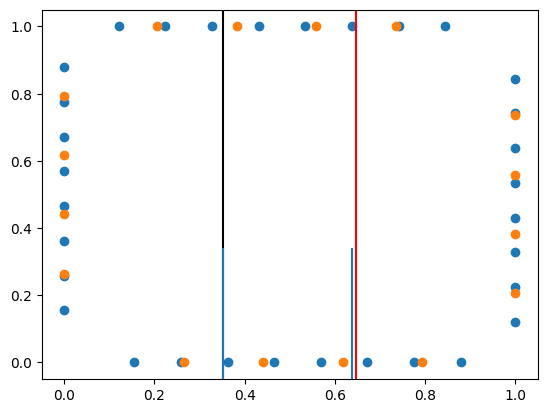

In [20]:
frac1 = get_fractional(HamElec1)
frac2 = get_fractional(HamElec2)
c1 = find_corners(HamElec1)
c2 = find_corners(HamElec2)
pc1, eidx1 = find_pair_edges(HamElec1, c1)
pc2, eidx2 = find_pair_edges(HamElec2, c2)
fpc1 = get_fractional(HamElec1, coords=pc1)
fpc2 = get_fractional(HamElec2, coords=pc2)

num_corners = 2

fig, ax = plt.subplots()

ax.scatter(*fpc2.T)
ax.scatter(*fpc1.T)

# bottom edge

from scipy.spatial import Voronoi
D = Voronoi(fpc1[:N1])
vert = D.vertices
print(vert)
ax.axvline(fpc1[:2].mean(axis=0)[0], color='k')
ax.axvline(fpc1[-2:].mean(axis=0)[0], color='r')
ax.axvline(vert[1,0], ymax=vert[1,1])
ax.axvline(vert[0,1], ymax=vert[1,0])
print(fpc1[-2:])
eb = fpc1[:N1-num_corners]
# print(eb[:])
DomainBottom = (eb[1:, :] - eb[:-1, :]).squeeze()
# print(DomainBottom[:])
# ax.axvline(DomainBottom[0])

In [21]:
?D

Type:        Voronoi
String form: <scipy.spatial._qhull.Voronoi object at 0x799ec91b7b60>
File:        ~/projects/QTM-ML/.venv/lib/python3.13/site-packages/scipy/spatial/_qhull.cpython-313-x86_64-linux-gnu.so
Docstring:  
Voronoi(points, furthest_site=False, incremental=False, qhull_options=None)

Voronoi diagrams in N dimensions.

.. versionadded:: 0.12.0

Parameters
----------
points : ndarray of floats, shape (npoints, ndim)
    Coordinates of points to construct a Voronoi diagram from
furthest_site : bool, optional
    Whether to compute a furthest-site Voronoi diagram. Default: False
incremental : bool, optional
    Allow adding new points incrementally. This takes up some additional
    resources.
qhull_options : str, optional
    Additional options to pass to Qhull. See Qhull manual
    for details. (Default: "Qbb Qc Qz Qx" for ndim > 4 and
    "Qbb Qc Qz" otherwise. Incremental mode omits "Qz".)

Attributes
----------
points : ndarray of double, shape (npoints, ndim)
    Coordi

# chatGPT suggestion

In [22]:
def find_edge_pairs(geom, corners, bond_threshold=1.5):
    """Find pairs of atoms that are connected by an edge, 
    and belong to different corners."""
    
    tree = cKDTree(geom.xyz)
    pairs = []
    for i in range(len(geom)):
        dists, idxs = tree.query(geom.xyz[i], k=10)
        for dist, idx in zip(dists, idxs):
            if dist < bond_threshold and idx != i:
                # Check if they belong to different corners
                corner_i = None
                corner_j = None
                for lab, idxs in corners.items():
                    if i in idxs:
                        corner_i = lab
                    if idx in idxs:
                        corner_j = lab
                if corner_i is not None and corner_j is not None and corner_i != corner_j:
                    pairs.append((i, idx))
    return pairs